In [1]:
from Utils import concatenate_df
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rashomon import get_rashomon, rashomon_ratio, rr_variation
import os
from sklearn.preprocessing import MinMaxScaler, RobustScaler
import plots
from sklearn.cluster import OPTICS
#import pacmap
from sklearn.decomposition import PCA
from joblib import load

## Importazione e Preprocessing dei df sulle metriche

### import metric df

In [2]:
full_df = concatenate_df(
    path = r'C:\Users\franc\OneDrive\Magistrale\Thesis-Model-Equivalence\Results\german\model_results', 
    file_names = '**_holdout'
)

cols_to_keep = [col for col in full_df.columns if col.startswith('val_') or col in ['model_id', 'model_type', 'n_neighbors']]
df = full_df[cols_to_keep]

In [3]:
len(df)

3080

### Baseline definition

In [4]:
baselines = concatenate_df(
    path = r'C:\Users\franc\OneDrive\Magistrale\Thesis-Model-Equivalence\Results\german\baseline\baselines', 
    file_names = '*_holdout')

In [5]:
baseline = baselines[baselines['model_type'] == 'CatBoostClassifier']

### columns preprocessing

In [6]:
df.loc[:,'knn_complexity'] = 1 / df['n_neighbors']

C:\Users\franc\AppData\Local\Temp\ipykernel_9412\1493884864.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'knn_complexity'] = 1 / df['n_neighbors']


In [7]:
for col in ['val_equalized_odds', 'val_cuae','val_dem_parity', 'val_equal_opportunity', 'val_predictive_equality',
            'val_predictive_parity', 'val_neg_predictive_parity']:
    df.loc[:, f'{col}_inverted'] = 1 - df[col].abs()

C:\Users\franc\AppData\Local\Temp\ipykernel_9412\3651598690.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, f'{col}_inverted'] = 1 - df[col].abs()
C:\Users\franc\AppData\Local\Temp\ipykernel_9412\3651598690.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, f'{col}_inverted'] = 1 - df[col].abs()
C:\Users\franc\AppData\Local\Temp\ipykernel_9412\3651598690.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

### single families df

In [8]:
rtc_df = df[df['model_type'] == 'RuleTreeClassifier'].dropna(axis = 1)
knn_df = df[df['model_type'] == 'knn'].dropna(axis = 1)
lr_df = df[df['model_type'] == 'LogisticRegression'].dropna(axis = 1)

### scaling

In [9]:
scaler = MinMaxScaler().set_output(transform = 'pandas')

scaled_df = scaler.fit_transform(df.select_dtypes('number'))
scaled_rtc = scaler.fit_transform(rtc_df.select_dtypes('number'))
scaled_knn = scaler.fit_transform(knn_df.select_dtypes('number'))
scaled_lr = scaler.fit_transform(lr_df.select_dtypes('number'))

## Features selection

In [10]:
def get_pca_metrics(df, family = None, n_components = 1):
    pca = PCA(n_components = n_components)
    
    performance = pca.fit_transform(df[['val_accuracy', 'val_f1', 'val_precision', 'val_recall']])
    fairness = pca.fit_transform(df[['val_equalized_odds_inverted', 'val_cuae_inverted','val_dem_parity_inverted', 'val_equal_opportunity_inverted',
                                     'val_predictive_equality_inverted', 'val_predictive_parity_inverted', 'val_neg_predictive_parity_inverted']])
    fair_robustness = pca.fit_transform(df[['val_dem_parity_robustness', 'val_equal_opp_robustness', 'val_predictive_eq_robustness',
                                                           'val_pred_parity_robustness', 'val_neg_pred_parity_robustness',
                                                           'val_eq_odds_robustness']])
    
    perf_robustness = pca.fit_transform(df[['val_acc_robustness', 'val_f1_robustness', 'val_precision_robustness', 'val_recall_robustness']])
    
    if family == 'rtc':
        complexity = pca.fit_transform(df[['val_rtc_depth', 'val_rtc_n_nodes', 'val_rtc_n_rules']])[:,0]
    elif family == 'knn':
        complexity = df['knn_complexity'].values
    else:
        complexity = df['val_coeff_magnitude'].values

    d = {
        'performance': performance[:,0], 
        'fairness': fairness[:,0], 
        'fair_robustness': fair_robustness[:,0], 
        'perf_robustness': perf_robustness[:,0], 
        'complexity': complexity
    }

    return pd.DataFrame(d)

In [11]:
rtc_pca = get_pca_metrics(scaled_rtc, family='rtc')
knn_pca = get_pca_metrics(scaled_knn, family='knn')
lr_pca = get_pca_metrics(scaled_lr, family='lr')

full_pca = get_pca_metrics(scaled_df)

embedding = pacmap.PaCMAP(n_components=2, n_neighbors=10, MN_ratio=3.0, FP_ratio=0.5, random_state = 0) 
cmap_data = embedding.fit_transform(scaled_data, init = 'pca')

## Correlation study

In [12]:
def plot_corr_matrix(corr_matrix, figsize:tuple = (12, 10), annot = True, title = None, save_plot = False, file_dir = '.', cbar = False):
    plt.figure(figsize = figsize)
    sns.heatmap(corr_matrix, annot = annot, cbar = cbar, fmt = '.2f', cmap = 'coolwarm')
    if title:
        plt.title(title)
    if save_plot:
        if not os.path.exists(file_dir):
            os.makedirs(file_dir, exist_ok = True)
        plt.savefig(os.path.join(file_dir, f'{title}.png'), dpi = 300, bbox_inches = 'tight')
    plt.show()

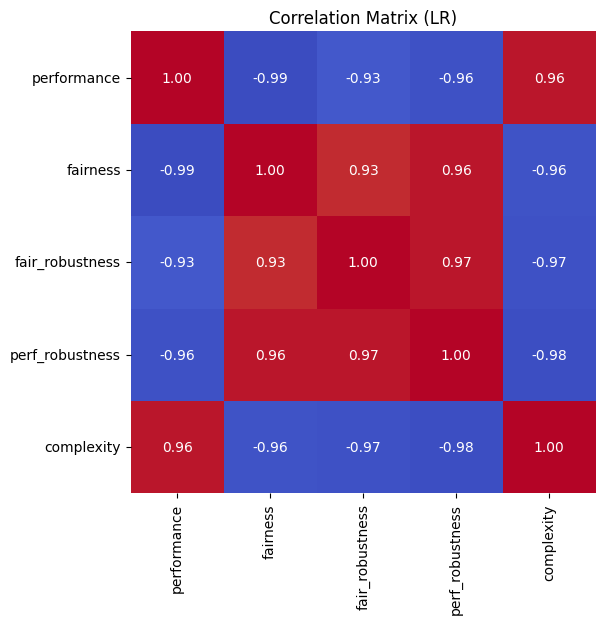

In [13]:
corr_df = rtc_df[['val_equal_opportunity',
       'val_equalized_odds', 'val_cuae', 'val_dem_parity',
       'val_predictive_equality', 'val_predictive_parity',
       'val_neg_predictive_parity']]
plot_corr_matrix(lr_pca.corr(), save_plot = True, title = 'Correlation Matrix (LR)', 
                 figsize = (6,6), file_dir = r'C:\Users\franc\OneDrive\Magistrale\Thesis-Model-Equivalence\Results\german\plots')

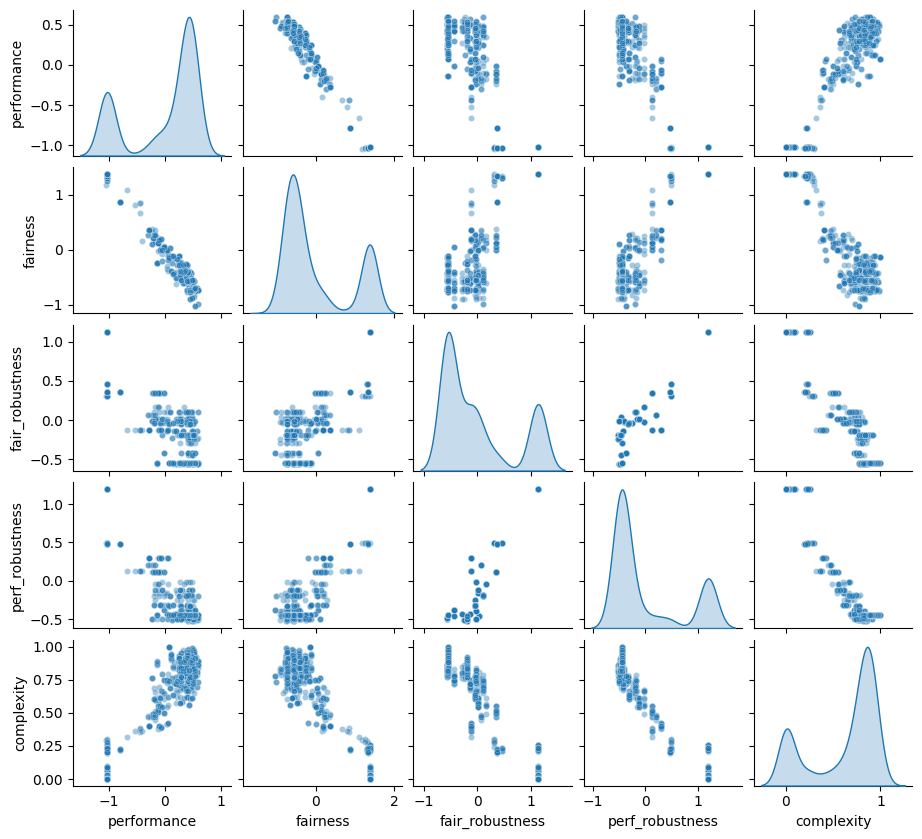

In [14]:
sns.pairplot(lr_pca.select_dtypes('number'), diag_kind='kde', height=1.7, aspect=1.1, plot_kws={'alpha': 0.4, 's': 20})


file_dir = r'C:\Users\franc\OneDrive\Magistrale\Thesis-Model-Equivalence\Results\german\plots'
title = 'corr(LR)'
plt.savefig(os.path.join(file_dir, f'{title}.png'), dpi = 300, bbox_inches = 'tight')
plt.show()
             

In [15]:
df.columns

Index(['model_id', 'model_type', 'n_neighbors', 'val_accuracy', 'val_f1',
       'val_precision', 'val_recall', 'val_equalized_odds', 'val_cuae',
       'val_dem_parity', 'val_equal_opportunity', 'val_predictive_equality',
       'val_predictive_parity', 'val_neg_predictive_parity',
       'val_acc_robustness', 'val_f1_robustness', 'val_precision_robustness',
       'val_recall_robustness', 'val_dem_parity_robustness',
       'val_equal_opp_robustness', 'val_predictive_eq_robustness',
       'val_pred_parity_robustness', 'val_neg_pred_parity_robustness',
       'val_eq_odds_robustness', 'val_coeff_magnitude', 'val_rtc_depth',
       'val_rtc_n_nodes', 'val_rtc_n_rules', 'knn_complexity',
       'val_equalized_odds_inverted', 'val_cuae_inverted',
       'val_dem_parity_inverted', 'val_equal_opportunity_inverted',
       'val_predictive_equality_inverted', 'val_predictive_parity_inverted',
       'val_neg_predictive_parity_inverted'],
      dtype='object')

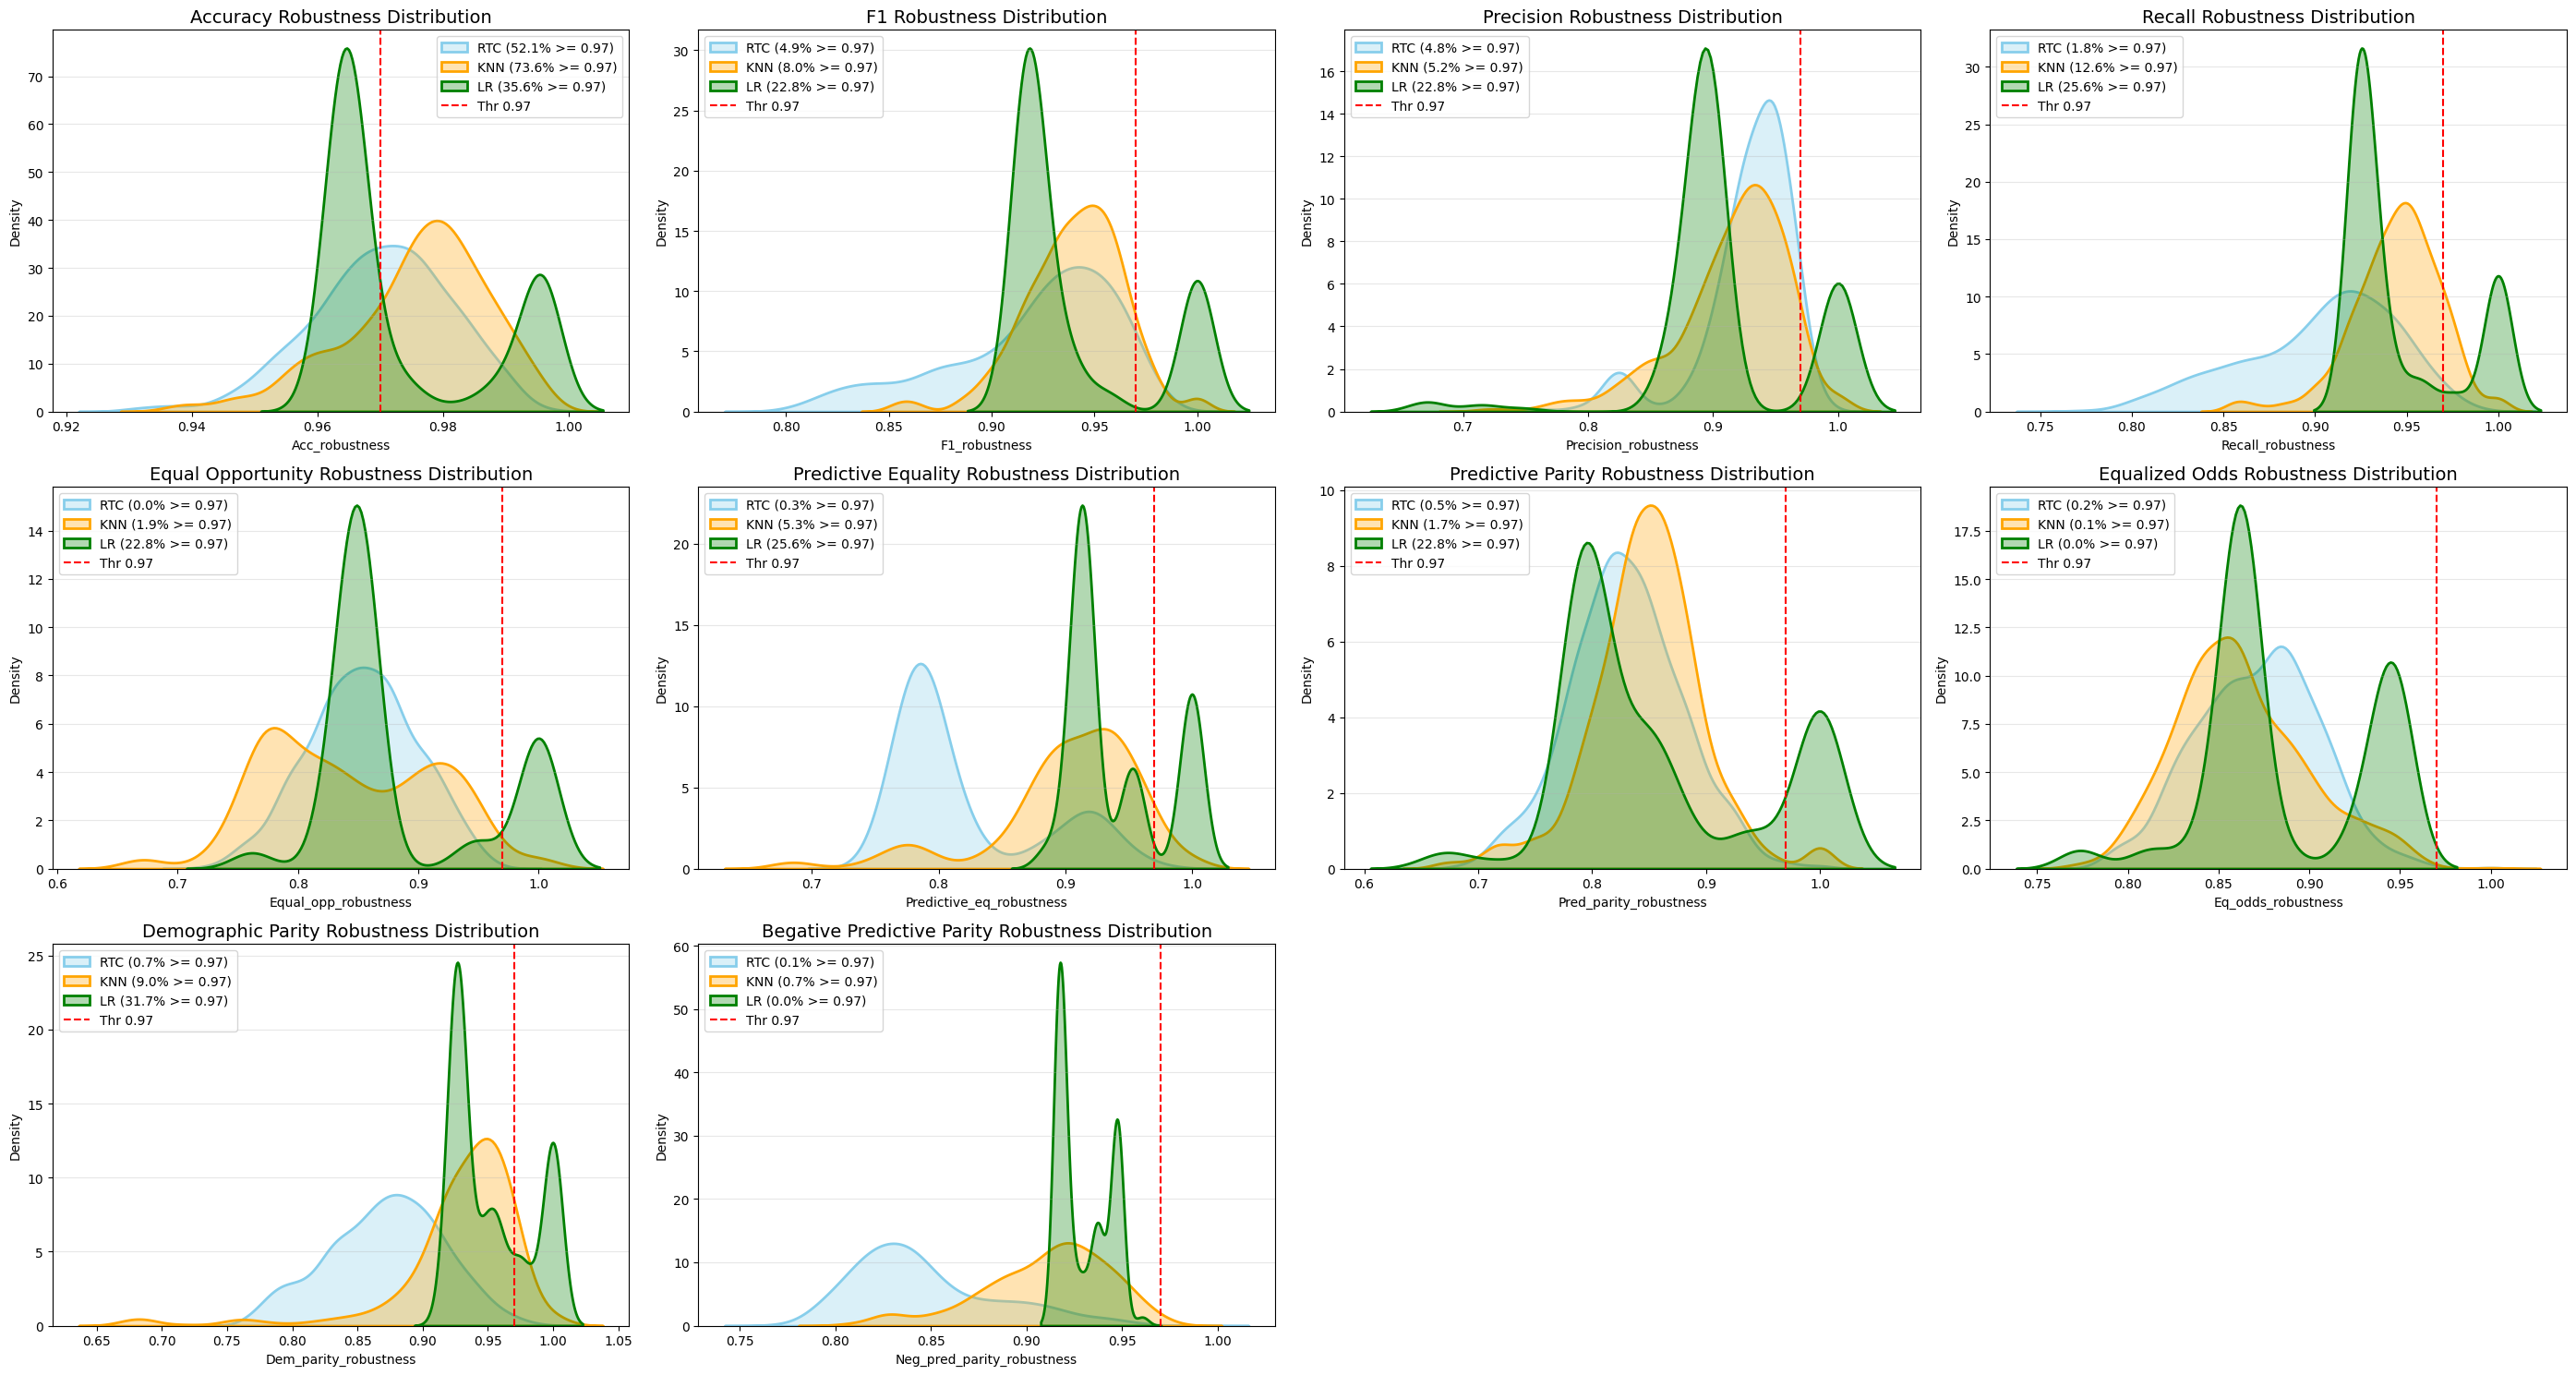

In [16]:
config_metriche = [
    #{'metrica': 'val_accuracy', 'soglia': 0.73, 'titolo': 'Accuracy Distribution'},
    #{'metrica': 'val_f1', 'soglia': 0.55, 'titolo': 'F1 Distribution'},
    #{'metrica': 'val_precision', 'soglia': 0.6, 'titolo': 'Precision Distribution'},
    #{'metrica': 'val_recall', 'soglia': 0.55, 'titolo': 'Recall Distribution'}
    
    #{'metrica': 'val_dem_parity', 'soglia': 0.1, 'titolo': 'Demographic Parity Difference Distribution'},
    #{'metrica': 'val_equalized_odds', 'soglia': 0.1, 'titolo': 'Equalized Odds Difference Distribution'},
    #{'metrica': 'val_equal_opportunity', 'soglia': 0.1, 'titolo': 'Equal Opportunity Distribution'},
    #{'metrica': 'val_predictive_equality', 'soglia': 0.1, 'titolo': 'Predictive Equality Distribution'},
    #{'metrica': 'val_predictive_parity', 'soglia': 0.1, 'titolo': 'Predictive Parity Distribution'},
    #{'metrica': 'val_neg_predictive_parity', 'soglia': 0.1, 'titolo': 'Negative Predictive Parity Distribution'},
    #{'metrica': 'val_cuae', 'soglia': 0.1, 'titolo': 'Conditional Use Accuracy Equality Difference (CUAE) Distribution'}

    {'metrica': 'val_acc_robustness', 'soglia': 0.97, 'titolo': 'Accuracy Robustness Distribution'},
    {'metrica': 'val_f1_robustness', 'soglia': 0.97, 'titolo': 'F1 Robustness Distribution'},
    {'metrica': 'val_precision_robustness', 'soglia': 0.97, 'titolo': 'Precision Robustness Distribution'},
    {'metrica': 'val_recall_robustness', 'soglia': 0.97, 'titolo': 'Recall Robustness Distribution'},
    {'metrica': 'val_equal_opp_robustness', 'soglia': 0.97, 'titolo': 'Equal Opportunity Robustness Distribution'},
    {'metrica': 'val_predictive_eq_robustness', 'soglia': 0.97, 'titolo': 'Predictive Equality Robustness Distribution'},
    {'metrica': 'val_pred_parity_robustness', 'soglia': 0.97, 'titolo': 'Predictive Parity Robustness Distribution'},
    {'metrica': 'val_eq_odds_robustness', 'soglia': 0.97, 'titolo': 'Equalized Odds Robustness Distribution'},
    {'metrica': 'val_dem_parity_robustness', 'soglia': 0.97, 'titolo': 'Demographic Parity Robustness Distribution'},
    {'metrica': 'val_neg_pred_parity_robustness', 'soglia': 0.97, 'titolo': 'Begative Predictive Parity Robustness Distribution'}
]

dataframes = [rtc_df, knn_df, lr_df]
labels = ['RTC', 'KNN', 'LR']
colors = ['skyblue', 'orange', 'green']

fig, axs = plt.subplots(3, 4, figsize=(28, 15))
axs = axs.flatten()
for i, metrica in enumerate(config_metriche):
    ax = axs[i]
    col = metrica['metrica']
    soglia = metrica['soglia']
    
    for ds, label, color in zip(dataframes, labels, colors):
        if metrica['metrica'] in ['val_equalized_odds', 'val_cuae', 'val_dem_parity', 'val_equal_opportunity', 'val_predictive_equality',
                                  'val_predictive_parity', 'val_neg_predictive_parity']:
            perc = (len(ds[ds[col] <= soglia]) - len(ds[ds[col] <= -soglia])) / len(ds) * 100
            sns.kdeplot(ds[col], 
                        fill=True, 
                        color=color, 
                        alpha=0.3,
                        label=f'{label} ({-soglia} <= {perc:.1f}% <= {soglia})',
                        linewidth=2,
                        ax=ax) 
        else:
            perc = len(ds[ds[col] >= soglia]) / len(ds) * 100
            sns.kdeplot(ds[col], 
                        fill=True, 
                        color=color, 
                        alpha=0.3,
                        label=f'{label} ({perc:.1f}% >= {soglia})',
                        linewidth=2,
                        ax=ax) 

    if metrica['metrica'] in ['val_equalized_odds', 'val_cuae', 'val_dem_parity', 'val_equal_opportunity', 'val_predictive_equality',
                                  'val_predictive_parity', 'val_neg_predictive_parity']:
        ax.axvline(-soglia, color='red', linestyle='--', linewidth=1.5, label=f'Thr {-soglia}')
    ax.axvline(soglia, color='red', linestyle='--', linewidth=1.5, label=f'Thr {soglia}')
    ax.set_title(metrica['titolo'], fontsize=14)
    ax.set_xlabel(col.replace('val_', '').capitalize())
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

for j in range(len(config_metriche), len(axs)):
    axs[j].axis('off')
plt.tight_layout()

file_dir = r'C:\Users\franc\OneDrive\Magistrale\Thesis-Model-Equivalence\Results\german\plots'
title = 'Robustness distributions'
#plt.savefig(os.path.join(file_dir, f'{title}.png'), dpi = 300, bbox_inches = 'tight')
plt.show()

## Rashomon Set Study

In [17]:
def rr_variation(df, threshold, tol, metric):
    ratios = []
    for t in tol:
        cond = f'{metric} >= {threshold - (threshold*t)}'
        ratio = rashomon_ratio(df, cond)        
        ratios.append(ratio)
    return ratios

In [18]:
epsilon = 0.2
thr = baseline['val_f1'].iloc[0]
soglia = thr - (epsilon*thr)
cond = f'val_f1 >= {soglia}'

dati = [
    {'fam': 'RTC','metric': np.sort(rtc_df['val_f1'].values), 'rr': rashomon_ratio(rtc_df, cond),'rr_var': rr_variation(rtc_df, thr, tol = np.linspace(0, 1, 50), metric = 'val_f1')},
    {'fam': 'KNN','metric': np.sort(knn_df['val_f1'].values), 'rr': rashomon_ratio(knn_df, cond),'rr_var': rr_variation(knn_df, thr, tol = np.linspace(0, 1, 50), metric = 'val_f1')},
    {'fam': 'LR','metric': np.sort(lr_df['val_f1'].values), 'rr': rashomon_ratio(lr_df, cond), 'rr_var': rr_variation(lr_df, thr, tol = np.linspace(0, 1, 50), metric = 'val_f1')}
]

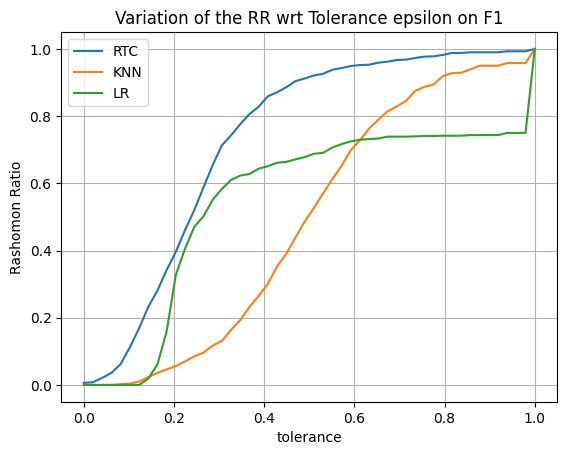

In [19]:
for el in dati:
    plt.plot(np.linspace(0, 1, 50), el['rr_var'], label = el['fam'])
plt.grid()
plt.legend()
plt.xlabel('tolerance')
plt.ylabel('Rashomon Ratio')
plt.title('Variation of the RR wrt Tolerance epsilon on F1')

file_dir = r'C:\Users\franc\OneDrive\Magistrale\Thesis-Model-Equivalence\Results\german\plots'
title = 'rr variation'
#plt.savefig(os.path.join(file_dir, f'{title}.png'), dpi = 300, bbox_inches = 'tight')
plt.show()

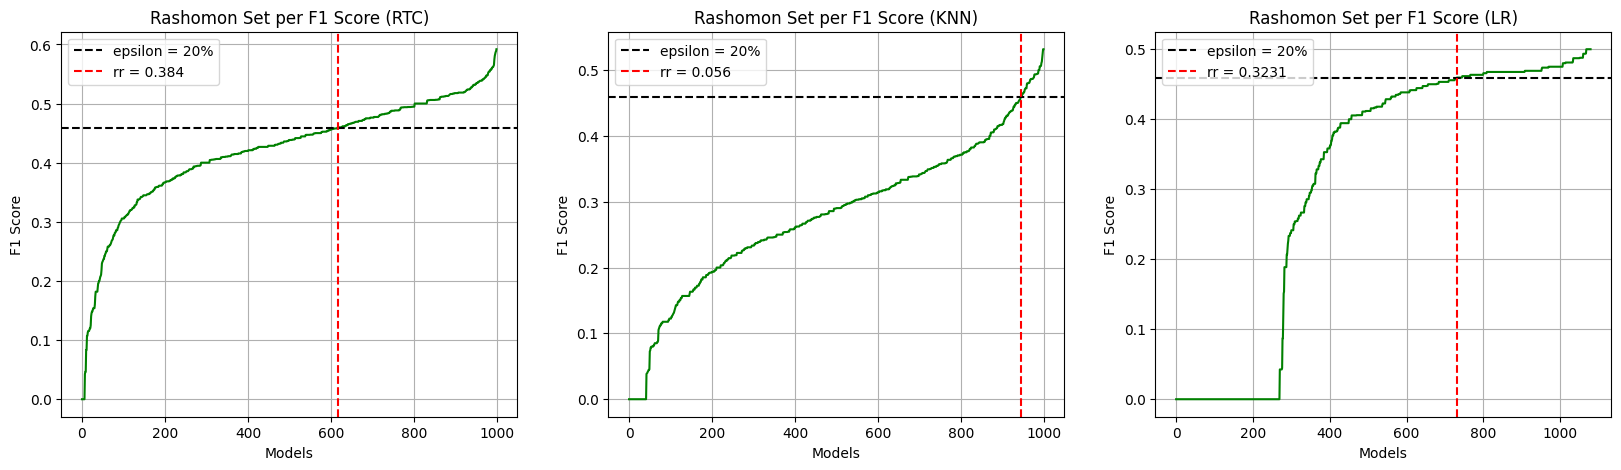

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
for i, ax in enumerate(axs):
    ax.plot(dati[i]['metric'], color = 'g') 
    ax.axhline(y = soglia, color='black', linestyle='--', label=f'epsilon = {int(epsilon*100)}%')
    ax.axvline(x = (1 - dati[i]['rr'])*1000 if dati[i]['fam'] != 'LR' else (1 - dati[i]['rr'])*1080, 
               color='red', linestyle='--', label=f'rr = {round(dati[i]['rr'], 4)}')
    ax.set_title(f'Rashomon Set per F1 Score ({dati[i]['fam']})')
    ax.legend()
    ax.grid()
    ax.set_xlabel('Models')
    ax.set_ylabel('F1 Score')

file_dir = r'C:\Users\franc\OneDrive\Magistrale\Thesis-Model-Equivalence\Results\german\plots'
title = 'rr 0.2'
#plt.savefig(os.path.join(file_dir, f'{title}.png'), dpi = 300, bbox_inches = 'tight')
plt.show()

### Rashomon Set definition

In [21]:
rtc_rash_set, rtc_rash_df = get_rashomon(rtc_df, cond)
knn_rash_set, knn_rash_df = get_rashomon(knn_df, cond)
lr_rash_set, lr_rash_df = get_rashomon(lr_df, cond)
rash_set, rash_df = get_rashomon(df, cond)

In [47]:
cols = ['model_id', 'model_type']
for c in cols:
    rtc_pca[c] = rtc_df[c].values
    knn_pca[c] = knn_df[c].values
    lr_pca[c] = lr_df[c].values
    full_pca[c] = df[c].values

rtc_rash_pca = rtc_pca[rtc_pca['model_id'].isin(rtc_rash_set)] 
knn_rash_pca = knn_pca[knn_pca['model_id'].isin(knn_rash_set)] 
lr_rash_pca = lr_pca[lr_pca['model_id'].isin(lr_rash_set)]
rash_pca = full_pca[full_pca['model_id'].isin(rash_set)]

In [48]:
data = [rtc_pca, knn_pca, lr_pca, full_pca]
rash = [rtc_rash_set, knn_rash_set, lr_rash_set, rash_set]

for d, r in zip(data, rash):
    d['is_rashomon'] = d['model_id'].isin(r).astype(int)

In [53]:
rash_pca['model_type'].unique()

array(['knn', 'LogisticRegression', 'RuleTreeClassifier'], dtype=object)

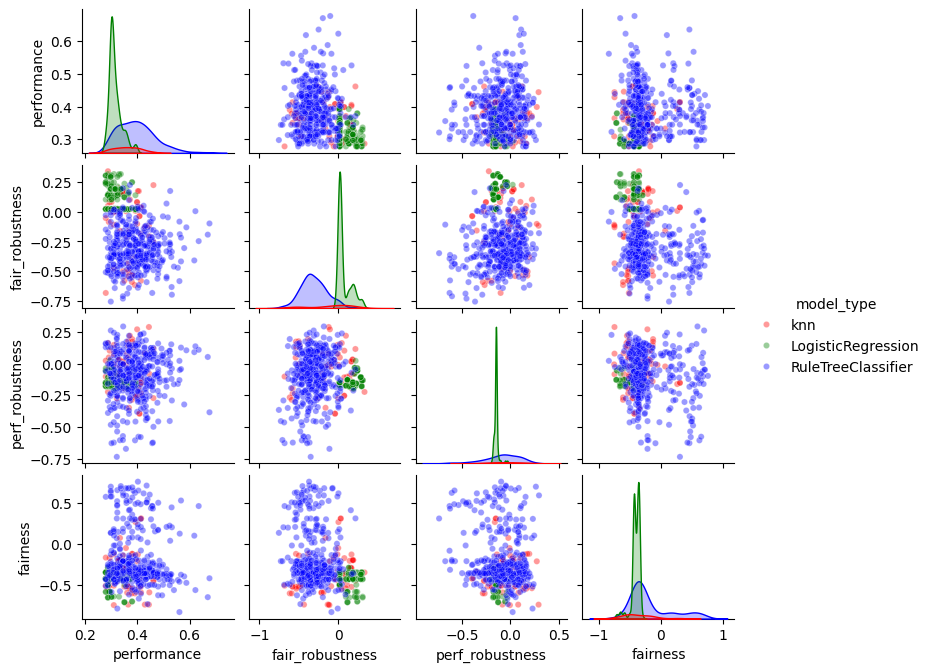

In [66]:
sns.pairplot(rash_pca,
             vars =  rash_pca[['performance','fair_robustness','perf_robustness','fairness']].columns.tolist(),
             diag_kind='kde', height=1.7, aspect=1.1, 
             plot_kws={'alpha': 0.4, 's': 20}, hue = 'model_type', palette = {'RuleTreeClassifier': 'blue', 
                                                                              'LogisticRegression': 'green',
                                                                              'knn': 'red'
                                                                             })


file_dir = r'C:\Users\franc\OneDrive\Magistrale\Thesis-Model-Equivalence\Results\german\plots'
title = 'corr_r(TOT)'
#plt.savefig(os.path.join(file_dir, f'{title}.png'), dpi = 300, bbox_inches = 'tight')
plt.show()


fig = plt.figure(figsize=(7, 5))
fig.subplots_adjust(left=0, right=10, bottom=0, top=1)
ax = fig.add_subplot(111, projection='3d')

d = rash_pca
r = lr_rash_set
ax.scatter(
    d['performance'],
    d['fairness'],
    d['complexity'],
    #c = d['model_type'].map({'RuleTreeClassifier': 'blue', 'LogisticRegression': 'green','knn': 'red'}),
    s=50)

ax.set_xlabel('performance')
ax.set_ylabel('fairness')
ax.set_box_aspect(None, zoom=0.8)
ax.set_zlabel('complexity')
ax.set_title('Rashomon Set LR')
ax.view_init(elev=30, azim=-750) 

file_dir = r'C:\Users\franc\OneDrive\Magistrale\Thesis-Model-Equivalence\Results\german\plots'
title = 'rs (LR)'
#plt.savefig(os.path.join(file_dir, f'{title}.png'), dpi = 300, bbox_inches = 'tight')
plt.show()

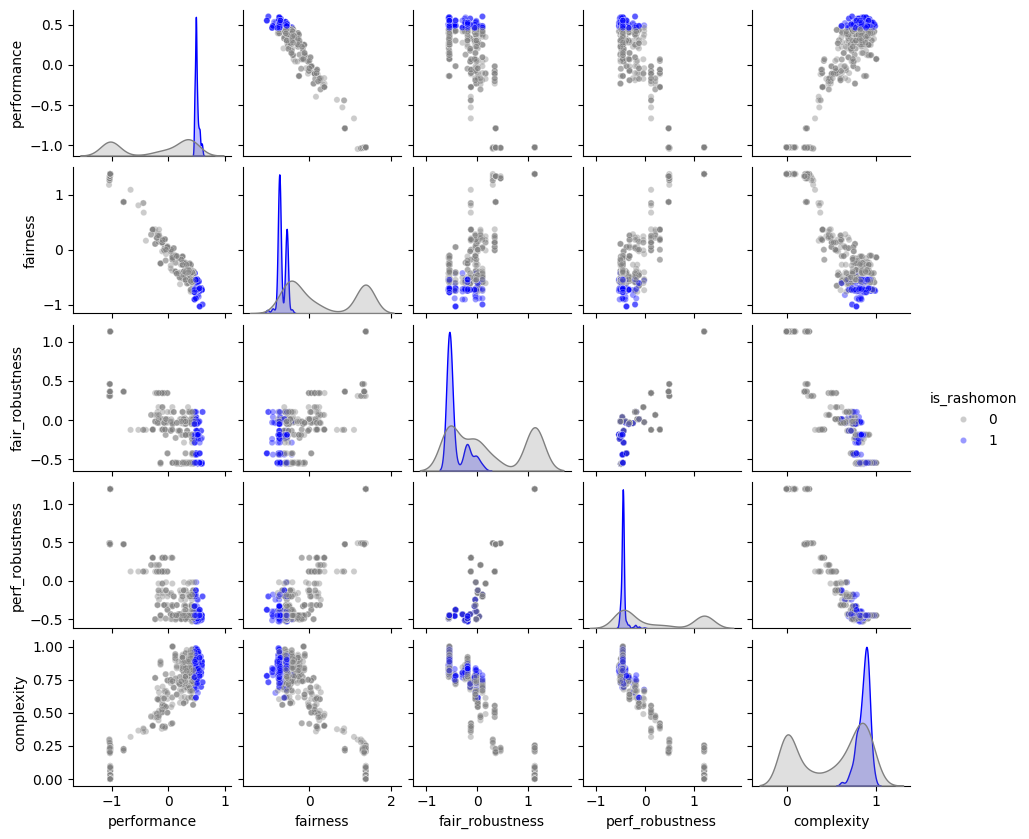

In [43]:
sns.pairplot(lr_pca.select_dtypes('number'), diag_kind='kde', height=1.7, aspect=1.1, 
             plot_kws={'alpha': 0.4, 's': 20}, hue = 'is_rashomon', palette = {1: 'blue', 0: 'grey'})


file_dir = r'C:\Users\franc\OneDrive\Magistrale\Thesis-Model-Equivalence\Results\german\plots'
title = 'corr_r(LR)'
#plt.savefig(os.path.join(file_dir, f'{title}.png'), dpi = 300, bbox_inches = 'tight')
plt.show()
             

In [67]:
rash_df.columns

Index(['model_id', 'model_type', 'n_neighbors', 'val_accuracy', 'val_f1',
       'val_precision', 'val_recall', 'val_equalized_odds', 'val_cuae',
       'val_dem_parity', 'val_equal_opportunity', 'val_predictive_equality',
       'val_predictive_parity', 'val_neg_predictive_parity',
       'val_acc_robustness', 'val_f1_robustness', 'val_precision_robustness',
       'val_recall_robustness', 'val_dem_parity_robustness',
       'val_equal_opp_robustness', 'val_predictive_eq_robustness',
       'val_pred_parity_robustness', 'val_neg_pred_parity_robustness',
       'val_eq_odds_robustness', 'val_coeff_magnitude', 'val_rtc_depth',
       'val_rtc_n_nodes', 'val_rtc_n_rules', 'knn_complexity',
       'val_equalized_odds_inverted', 'val_cuae_inverted',
       'val_dem_parity_inverted', 'val_equal_opportunity_inverted',
       'val_predictive_equality_inverted', 'val_predictive_parity_inverted',
       'val_neg_predictive_parity_inverted'],
      dtype='object')

In [62]:
to_see = [
for col in rash_df.columns:
    if col not in ['model_id', 'model_type']:
        print(f'{col}:\n{round(rtc_rash_df[col].min(), 3)}-{round(rtc_rash_df[col].max(), 3)} mean: {round(rtc_rash_df[col].mean(), 3)}, std: {round(rtc_rash_df[col].std(), 3)}')

KeyError: 'n_neighbors'

## Correlation btw models in/not in the rashomon set

In [8]:
not_rash_df = df[~ df['model_id'].isin(rash_df['model_id'])]

In [9]:
rash_corr_matrix = rash_df.select_dtypes(include=['number']).corr()
not_rash_corr_matrix = not_rash_df.select_dtypes(include=['number']).corr()

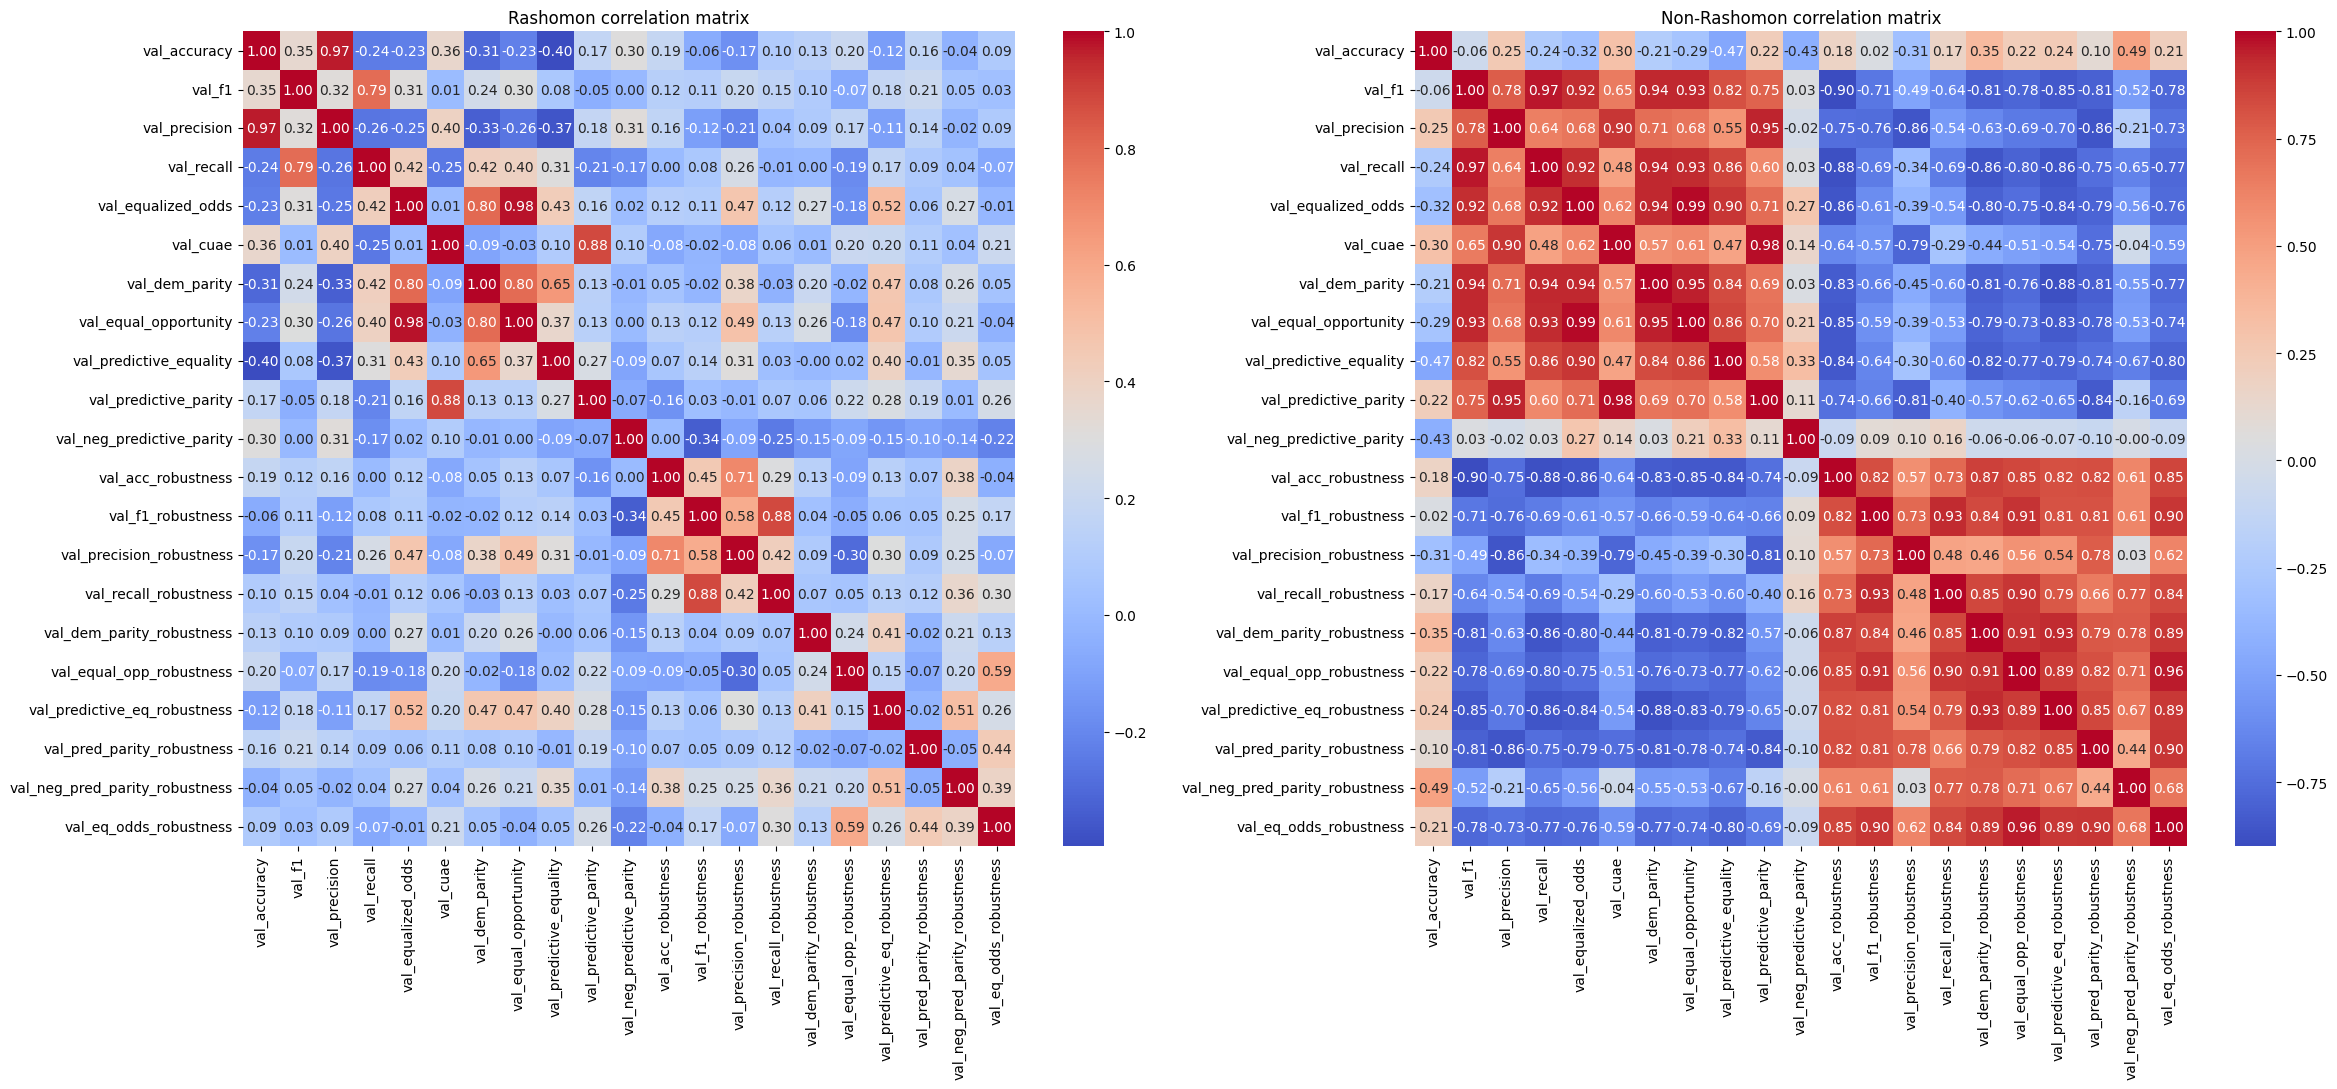

In [10]:
plots.plot_corr_matrix_grid([rash_corr_matrix, not_rash_corr_matrix],
                            ['Rashomon correlation matrix', 'Non-Rashomon correlation matrix'],
                            cols = 2,
                            annot = True,
                            figsize_unit = (12, 11)
                           )

In [45]:
df

,model_id,params,val_accuracy,val_f1,val_precision,val_recall,val_equalized_odds,val_cuae,val_dem_parity,val_equal_opportunity,...,val_acc_robustness,val_f1_robustness,val_precision_robustness,val_recall_robustness,val_dem_parity_robustness,val_equal_opp_robustness,val_predictive_eq_robustness,val_pred_parity_robustness,val_neg_pred_parity_robustness,val_eq_odds_robustness
0,3d3fbc9a0553c6433eb21980c33cef08,"{""criterion"": ""gini"", ""max_depth"": 20, ""min_sa...",0.735714,0.432733,0.606026,0.338095,0.383117,0.651465,0.196777,0.383117,...,0.975945,0.931484,0.932414,0.929083,0.907309,0.847498,0.910129,0.846705,0.883148,1.699011
1,0007f208a9ab574493a22ebdb26fedc7,"{""n_neighbors"": 8, ""p"": 1.6531, ""weights"": ""un...",0.697143,0.205443,0.495629,0.133333,0.254762,0.713333,0.149320,0.254762,...,0.975882,0.943201,0.866453,0.959559,0.959175,0.927581,0.921556,0.843011,0.889382,1.764795
2,003ce8c1d478af4bfebe9ae54f4328a1,"{""n_neighbors"": 5, ""p"": 1.5714, ""weights"": ""un...",0.695714,0.363110,0.494529,0.300000,0.450952,0.703333,0.232333,0.443810,...,0.965806,0.931962,0.916183,0.933548,0.897549,0.860094,0.892918,0.835642,0.870300,1.691409
3,00880a40ef0c9d858bcfaaafc640ac04,"{""n_neighbors"": 7, ""p"": 1.0, ""weights"": ""unifo...",0.705714,0.368541,0.520438,0.295238,0.396429,0.654286,0.267994,0.396429,...,0.971265,0.932226,0.910566,0.941550,0.950787,0.909178,0.931751,0.850892,0.883424,1.750346
4,00c82bb517ca675a88a1b651d1a0607f,"{""n_neighbors"": 5, ""p"": 3.6122, ""weights"": ""di...",0.665714,0.317155,0.425238,0.257143,0.394545,0.616667,0.166055,0.343810,...,0.961314,0.929512,0.910874,0.934956,0.925729,0.870629,0.918275,0.837906,0.875981,1.713111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2996,fe9487e8563fd82eb2192806c299015e,"{""criterion"": ""gini"", ""max_depth"": 13, ""min_sa...",0.715714,0.484584,0.538345,0.457143,0.433247,0.583889,0.227230,0.421429,...,0.962322,0.926140,0.919894,0.906016,0.898065,0.835672,0.887277,0.844218,0.842488,1.680570
2997,fed8b3588d6395ae7fc0dec4aeb7cac6,"{""criterion"": ""gini"", ""max_depth"": 11, ""min_sa...",0.722857,0.464168,0.559498,0.404762,0.577273,0.650693,0.266424,0.577273,...,0.968761,0.935879,0.933112,0.919919,0.911215,0.819659,0.889655,0.837993,0.858308,1.659888
2998,feda33151f51715f6308915bd5e043f4,"{""criterion"": ""gini"", ""max_depth"": 13, ""min_sa...",0.707143,0.408842,0.515616,0.342857,0.446499,0.724596,0.238749,0.446499,...,0.959038,0.913369,0.919394,0.899912,0.901436,0.853051,0.904078,0.828415,0.837840,1.684945
2999,fee349f0d2ea83cec17de24541bb0c2d,"{""criterion"": ""entropy"", ""max_depth"": 13, ""min...",0.707143,0.408842,0.515616,0.342857,0.446499,0.724596,0.238749,0.446499,...,0.960547,0.924540,0.923696,0.914447,0.880628,0.860699,0.886931,0.864677,0.840013,1.698321


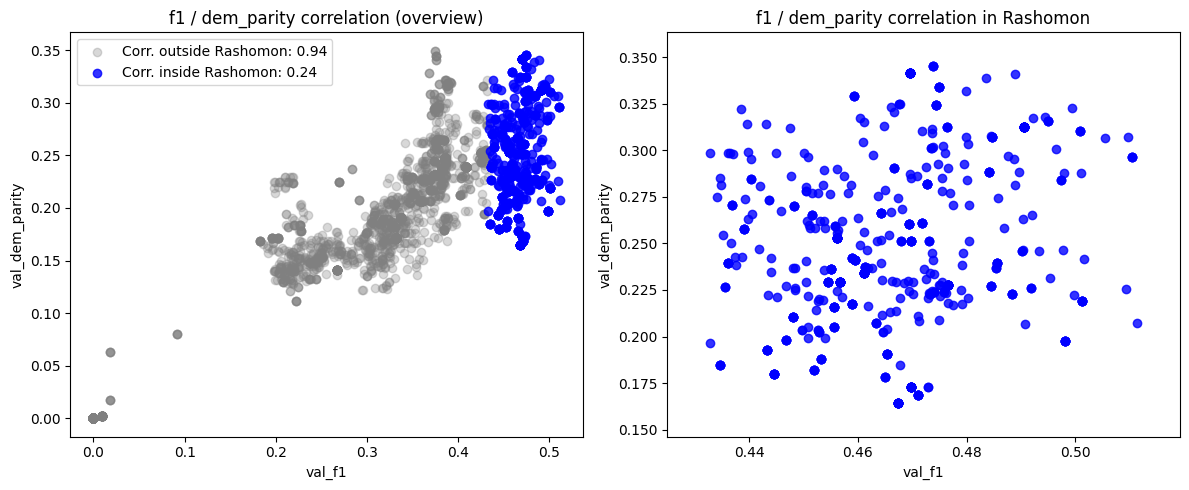

In [36]:
#val_recall
plots.plot_corr_scatter(rash_df, not_rash_df, x = 'val_f1', y = 'val_dem_parity',
                        titles = ['f1 / dem_parity correlation (overview)', 'f1 / dem_parity correlation in Rashomon'],
                       figsize = (12, 5))

## Clustering of Rashomon set

x = 'val_f1'
y = 'val_dem_parity'
z = 'val_f1_robustness'

plots.plot_rashomon(df, x, y, z, rash_models)

In [12]:
scaler = MinMaxScaler().set_output(transform = 'pandas')
scaled_rash_df = scaler.fit_transform(rash_df.select_dtypes(include=['number']))

In [13]:
scaled_rash_df.columns

Index(['val_accuracy', 'val_f1', 'val_precision', 'val_recall',
       'val_equalized_odds', 'val_cuae', 'val_dem_parity',
       'val_equal_opportunity', 'val_predictive_equality',
       'val_predictive_parity', 'val_neg_predictive_parity',
       'val_acc_robustness', 'val_f1_robustness', 'val_precision_robustness',
       'val_recall_robustness', 'val_dem_parity_robustness',
       'val_equal_opp_robustness', 'val_predictive_eq_robustness',
       'val_pred_parity_robustness', 'val_neg_pred_parity_robustness',
       'val_eq_odds_robustness'],
      dtype='object')

In [14]:
fairness_df = scaled_rash_df[['val_equalized_odds', 'val_cuae', 'val_predictive_equality', 'val_neg_predictive_parity']].copy()

robustness_df = scaled_rash_df[['val_acc_robustness', 'val_f1_robustness', 'val_precision_robustness',
       'val_recall_robustness', 'val_dem_parity_robustness',
       'val_equal_opp_robustness', 'val_predictive_eq_robustness',
       'val_pred_parity_robustness', 'val_neg_pred_parity_robustness',
       'val_eq_odds_robustness']].copy()

In [15]:
len(fairness_df)

611

In [16]:
clustering = OPTICS(min_samples = 20, xi = 0.01).fit(fairness_df)

n_clusters = len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0)
n_noise = list(clustering.labels_).count(-1)/len(fairness_df)*100
print(f'n_clusters: \n{n_clusters}')
print(f'n_noise: \n{int(n_noise)}%')

n_clusters: 
8
n_noise: 
51%


C:\Users\franc\anaconda3\envs\py312\Lib\site-packages\sklearn\cluster\_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


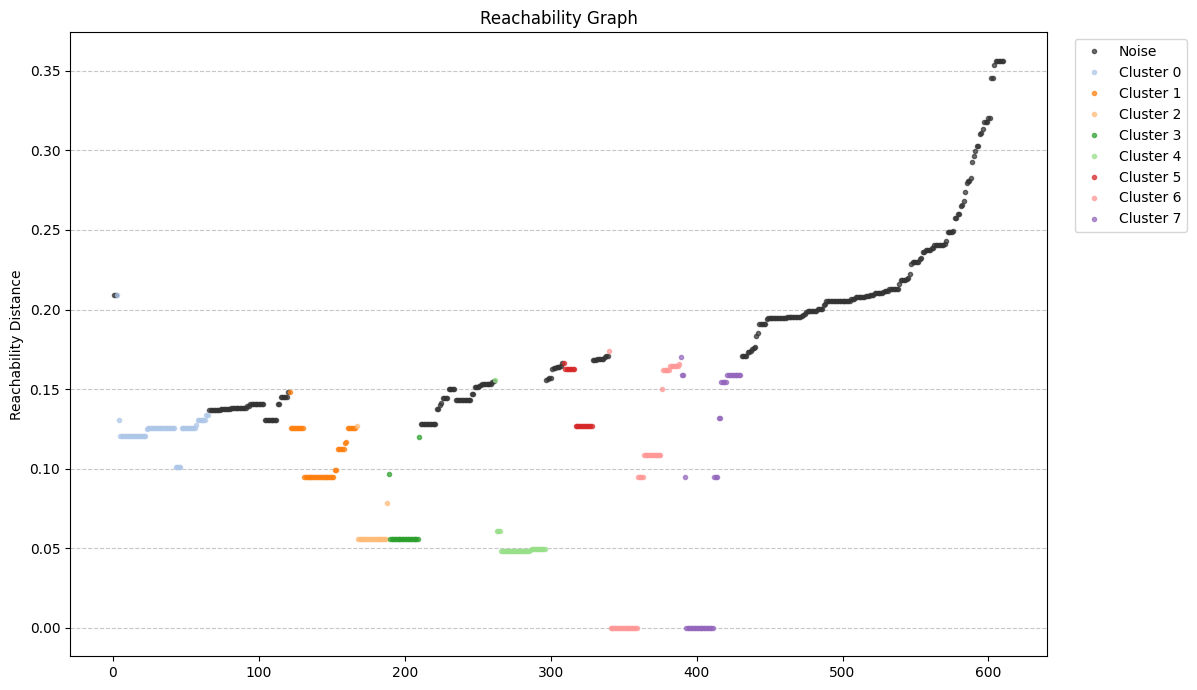

In [17]:
plots.plot_reachability_graph(clustering)

In [18]:
for cluster in np.unique(clustering.labels_):
    print(f'n models in cluster {cluster}: {list(clustering.labels_).count(cluster)}')

n models in cluster -1: 312
n models in cluster 0: 63
n models in cluster 1: 46
n models in cluster 2: 22
n models in cluster 3: 22
n models in cluster 4: 35
n models in cluster 5: 20
n models in cluster 6: 49
n models in cluster 7: 42


In [19]:
rash_df.columns

Index(['model_id', 'params', 'val_accuracy', 'val_f1', 'val_precision',
       'val_recall', 'val_equalized_odds', 'val_cuae', 'val_dem_parity',
       'val_equal_opportunity', 'val_predictive_equality',
       'val_predictive_parity', 'val_neg_predictive_parity',
       'val_acc_robustness', 'val_f1_robustness', 'val_precision_robustness',
       'val_recall_robustness', 'val_dem_parity_robustness',
       'val_equal_opp_robustness', 'val_predictive_eq_robustness',
       'val_pred_parity_robustness', 'val_neg_pred_parity_robustness',
       'val_eq_odds_robustness'],
      dtype='object')

In [20]:
rash_df_copy = rash_df.copy()
rash_df_copy['cluster'] = clustering.labels_


for cluster in np.unique(clustering.labels_):
    max_fairness = float('-inf')
    max_fairness_cluster = None
    fairness = rash_df_copy[rash_df_copy['cluster'] == cluster]['val_equalized_odds'].mean()
    print(f'avg fairness for cluster {cluster}:', fairness)
    if fairness > max_fairness:
        max_fairness = fairness
        max_fairness_cluster = cluster
print(f'\nmax fairness in cluster {max_fairness_cluster}')
    

avg fairness for cluster -1: 0.5004331519692773
avg fairness for cluster 0: 0.43014015427460806
avg fairness for cluster 1: 0.4439511575381141
avg fairness for cluster 2: 0.4247871068325612
avg fairness for cluster 3: 0.45353464717101066
avg fairness for cluster 4: 0.38619152276295127
avg fairness for cluster 5: 0.45281818181818184
avg fairness for cluster 6: 0.55538203687272
avg fairness for cluster 7: 0.5581047206761491

max fairness in cluster 7


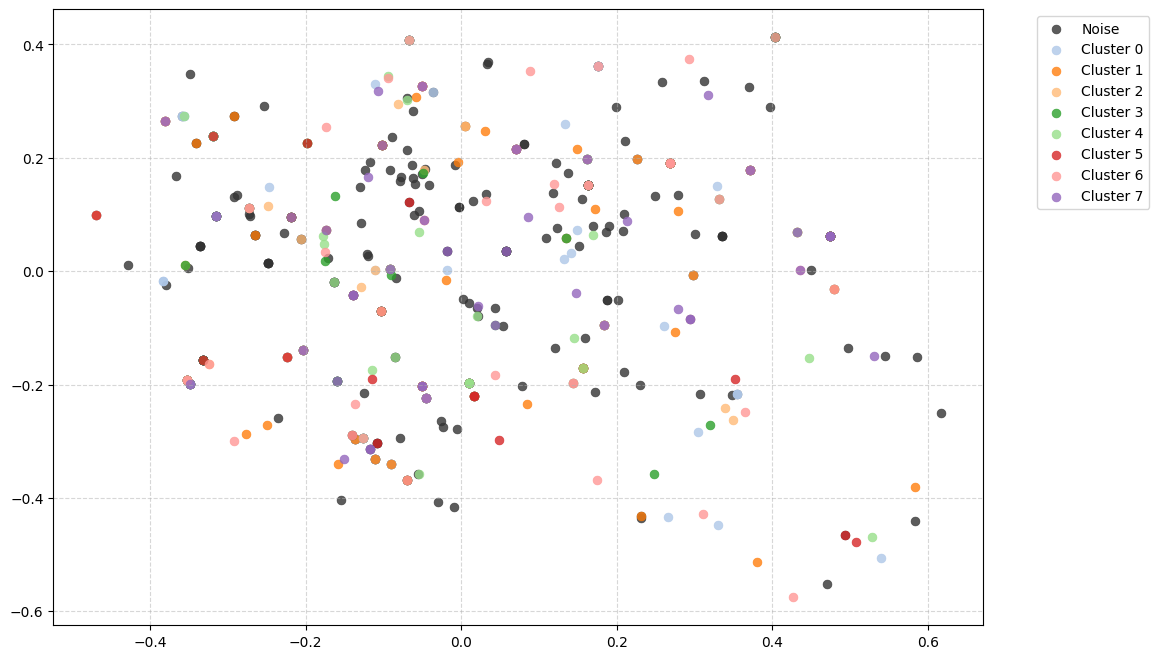

In [21]:
reduced_df = plots.feature_reduction(fairness_df, clustering, method = PCA)
plots.plot_clustering(reduced_df, clustering)